In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Loading dataset

In [2]:
data=pd.read_csv("C:/FIFA_data.csv",engine="python",encoding="latin-1")
pd.set_option("display.max_columns",None)
data.head(10)

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,110.5M,565K,2202,Left,5.0,4.0,4.0,Medium/ Medium,Messi,Yes,RF,10.0,"Jul 1, 2004",NaN,2021,5'7,159lbs,88+2,88+2,88+2,92+2,93+2,93+2,93+2,92+2,93+2,93+2,93+2,91+2,84+2,84+2,84+2,91+2,64+2,61+2,61+2,61+2,64+2,59+2,47+2,47+2,47+2,59+2,84.0,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,91.0,86.0,91.0,95.0,95.0,85.0,68.0,72.0,59.0,94.0,48.0,22.0,94.0,94.0,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,77M,405K,2228,Right,5.0,4.0,5.0,High/ Low,C. Ronaldo,Yes,ST,7.0,"Jul 10, 2018",NaN,2022,6'2,183lbs,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3,84.0,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,89.0,91.0,87.0,96.0,70.0,95.0,95.0,88.0,79.0,93.0,63.0,29.0,95.0,82.0,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,118.5M,290K,2143,Right,5.0,5.0,5.0,High/ Medium,Neymar,Yes,LW,10.0,"Aug 3, 2017",NaN,2022,5'9,150lbs,84+3,84+3,84+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,88+3,81+3,81+3,81+3,88+3,65+3,60+3,60+3,60+3,65+3,60+3,47+3,47+3,47+3,60+3,79.0,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,94.0,90.0,96.0,94.0,84.0,80.0,61.0,81.0,49.0,82.0,56.0,36.0,89.0,87.0,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,72M,260K,1471,Right,4.0,3.0,1.0,Medium/ Medium,Lean,Yes,GK,1.0,"Jul 1, 2011",NaN,2020,6'4,168lbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,57.0,58.0,60.0,90.0,43.0,31.0,67.0,43.0,64.0,12.0,38.0,30.0,12.0,68.0,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,102M,355K,2281,Right,4.0,5.0,4.0,High/ High,Normal,Yes,RCM,7.0,"Aug 30, 2015",NaN,2023,5'11,154lbs,82+3,82+3,82+3,87+3,87+3,87+3,87+3,87+3,88+3,88+3,88+3,88+3,87+3,87+3,87+3,88+3,77+3,77+3,77+3,77+3,77+3,73+3,66+3,66+3,66+3,73+3,93.0,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,78.0,76.0,79.0,91.0,77.0,91.0,63.0,90.0,75.0,91.0,76.0,61.0,87.0,94.0,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196.4M
5,5,183277,E. Hazard,27.0,https://cdn.sofifa.org/players/4/19/183277.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,91,Chelsea,https://cdn.sofifa.org/teams/2/light/5.png,93M,340K,2142,Right,4.0,4.0,4.0,High/ Medium,Normal,Yes,LF,10.0,"Jul 1, 2012",NaN,2020,5'8,163lbs,83+3,83+3,83+3,89+3,88+3,88+3,88+3,89+3,89+3,89+3,89

Preprocessing Analysis

In [3]:
data.columns

Index(['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag',
       'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW',
       'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM',
       'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingT

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18206 non-null  float64
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18206 non-null  float64
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 non-null  int64  
 14  Prefer

checking sum of null values

In [5]:
data.isnull().sum()

Unnamed: 0           0
ID                   0
Name                 0
Age                  1
Photo                0
                  ... 
GKHandling          48
GKKicking           48
GKPositioning       48
GKReflexes          48
Release Clause    1564
Length: 89, dtype: int64

<Axes: >

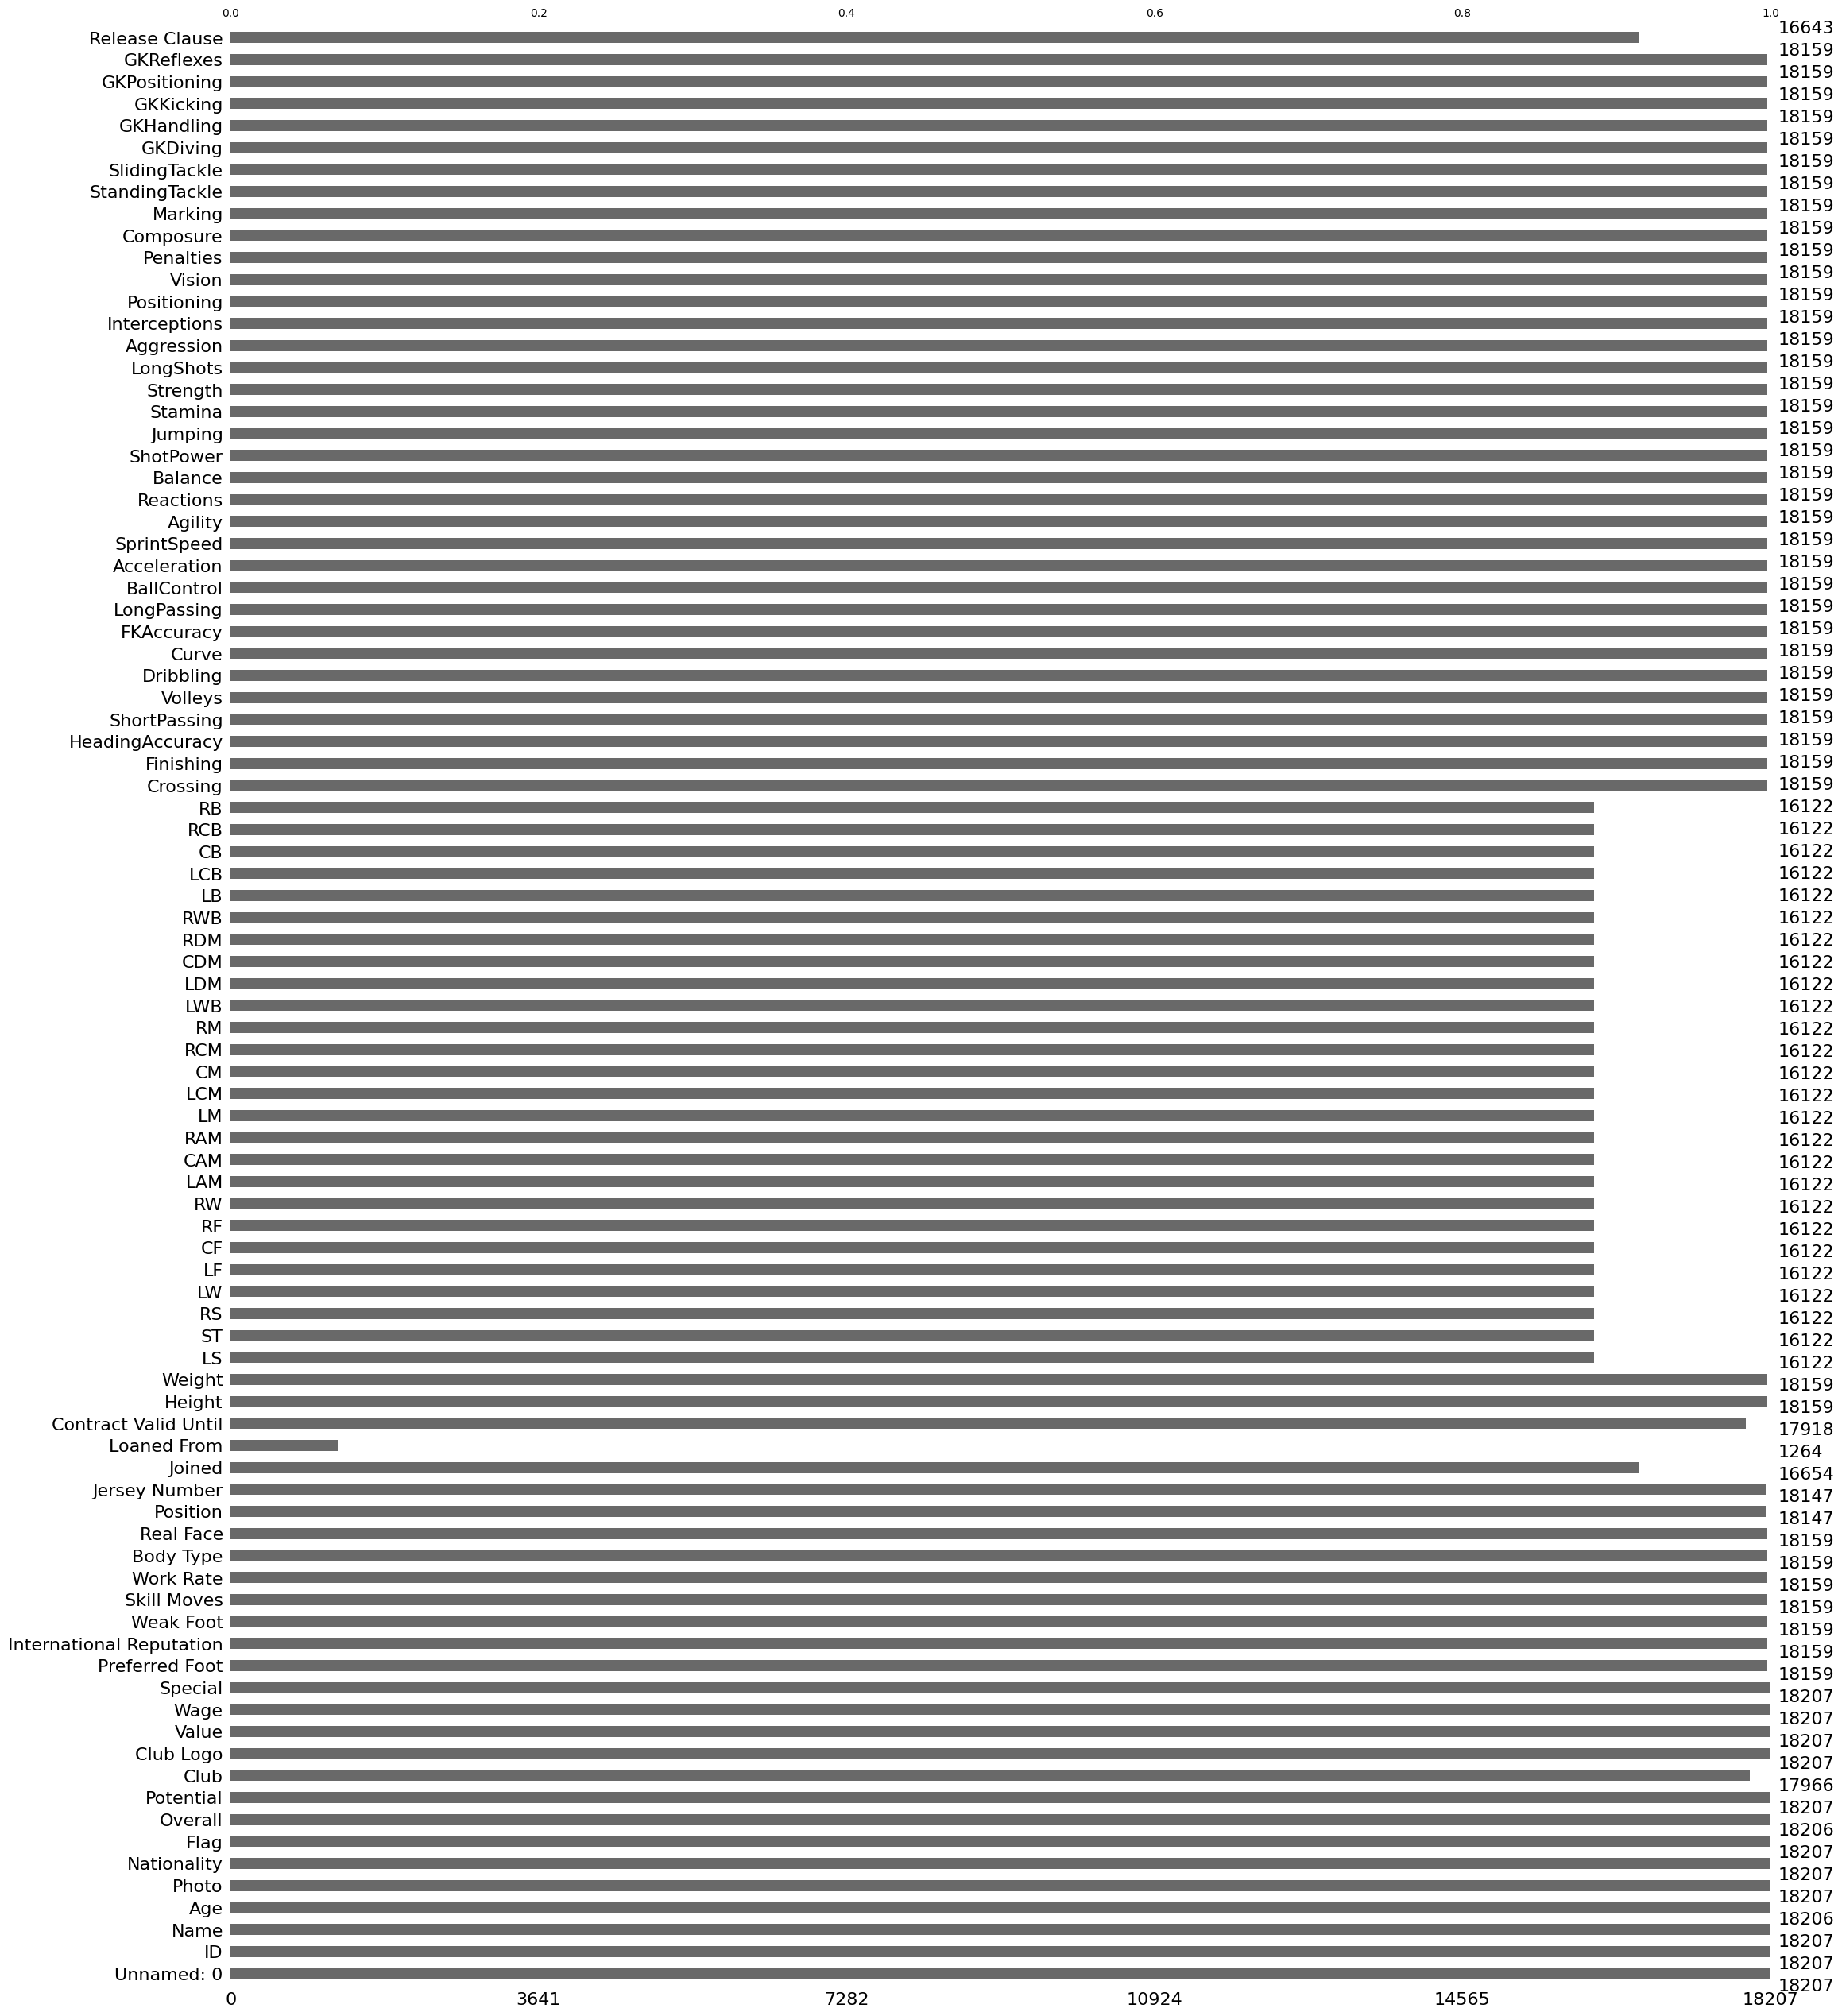

In [6]:
!pip install missingno
import missingno as msno
temp=data.iloc[:,0:90]
temp.shape
msno.bar(temp)

Analysis of Data

Filling missing values using mean,mode and median

In [7]:
cols_to_fix = [
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance', 
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes'
]

# Use direct assignment (much more reliable than inplace=True)
for col in cols_to_fix:
    data[col] = data[col].fillna(data[col].mean())

In [10]:
cols_to_fix = [
    'Body Type','International Reputation','Height', 'Weight','Preferred Foot','Jersey Number'
]

# Use direct assignment (much more reliable than inplace=True)
for col in cols_to_fix:
    data[col] = data[col].fillna(data[col].mode()[0])

In [11]:
cols_to_fix = [
    'Weak Foot','Skill Moves'
]

# Use direct assignment (much more reliable than inplace=True)
for col in cols_to_fix:
    data[col] = data[col].fillna(data[col].median())

In [12]:
data.isnull().sum()

Unnamed: 0           0
ID                   0
Name                 0
Age                  1
Photo                0
                  ... 
GKHandling           0
GKKicking            0
GKPositioning        0
GKReflexes           0
Release Clause    1564
Length: 89, dtype: int64

In [13]:
data.columns[data.isnull().any()]

Index(['Age', 'Overall', 'Club', 'Work Rate', 'Real Face', 'Position',
       'Joined', 'Loaned From', 'Contract Valid Until', 'LS', 'ST', 'RS', 'LW',
       'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM',
       'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB',
       'Release Clause'],
      dtype='object')

In [16]:
# Fill numeric columns with 0
data = data.fillna(data.select_dtypes(include='number').fillna(0))

# Fill string/object columns with '0'
data = data.fillna(data.select_dtypes(exclude='number').fillna('0'))

In [17]:
data.isnull().sum()

Unnamed: 0        0
ID                0
Name              0
Age               0
Photo             0
                 ..
GKHandling        0
GKKicking         0
GKPositioning     0
GKReflexes        0
Release Clause    0
Length: 89, dtype: int64

Changing datatypes

In [18]:
data["Age"] = data["Age"].astype(int)

In [19]:
data["Value"] = data["Value"].str.replace(r"[^\d\.MK]", "", regex=True)

In [20]:
data["Value"] = data["Value"].replace({'M':'e6', 'K':'e3'}, regex=True).astype(float)

In [21]:
data["Wage"] = data["Wage"].str.replace(r"[^\d\.MK]", "", regex=True)
data["Wage"] = data["Value"].replace({'M':'e6', 'K':'e3'}, regex=True).astype(float)

In [22]:
def convert_weight(w):
    if pd.isnull(w):
        return None
    w = str(w)
    
    if "kg" in w:
        return float(w.replace("kg", ""))
    
    elif "lbs" in w:
        return float(w.replace("lbs", "")) * 0.453592  # convert to kg
    
    else:
        return None

In [23]:
data["Weight"] = data["Weight"].apply(convert_weight)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18207 non-null  int64  
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18207 non-null  float64
 8   Potential                 18207 non-null  int64  
 9   Club                      18207 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  float64
 12  Wage                      18207 non-null  float64
 13  Special                   18207 non-null  int64  
 14  Prefer

Renaming columns

In [25]:
data.rename(columns={'Preferred Foot':'PreferredFoot',"International Reputation":"InternationalReputation",
                     'Weak Foot':'WeakFoot','Skill Moves':'SkillMoves','Work Rate':'WorkRate','Body Type':'BodyType',
                    'Real Face':'RealFace','Jersey Number':'JerseyNumber','Loaned From':'LoanedFrom','Contract Valid Until':'ContractValidUntil',
                    'Club Logo':'ClubLogo','Release Clause':'ReleaseClause'},
            inplace=True)

data.columns

Index(['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag',
       'Overall', 'Potential', 'Club', 'ClubLogo', 'Value', 'Wage', 'Special',
       'PreferredFoot', 'InternationalReputation', 'WeakFoot', 'SkillMoves',
       'WorkRate', 'BodyType', 'RealFace', 'Position', 'JerseyNumber',
       'Joined', 'LoanedFrom', 'ContractValidUntil', 'Height', 'Weight', 'LS',
       'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM', 'LM',
       'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB',
       'LCB', 'CB', 'RCB', 'RB', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKD

Adding columns

In [26]:
def defending (data1):
    return int(round(data1[['Marking','StandingTackle', 'SlidingTackle']].mean().mean()))
def general (data1):
    return int(round(data1[['HeadingAccuracy','Dribbling','Curve','BallControl']].mean().mean()))
def general (data1):
    return int(round(data1[['HeadingAccuracy','Dribbling','Curve','BallControl']].mean().mean()))
def mental (data1):
    return int(round(data1[['Aggression','Interceptions', 'Positioning', 'Vision', 'Composure']].mean().mean()))
def passing (data1):
    return int(round(data1[['Crossing','ShortPassing','LongPassing']].mean().mean()))
def mobility (data1):
    return int(round(data1[['Acceleration','SprintSpeed', 'Agility', 'Reactions']].mean().mean()))
def power (data1):
    return int(round(data1[['Balance','Jumping', 'Stamina', 'Strength']].mean().mean()))
def rating (data1):
    return int(round(data1[['Overall', 'Potential']].mean().mean()))
def shooting (data1):
    return int(round(data1[['Finishing','Volleys','FKAccuracy','ShotPower', 'LongShots','Penalties']].mean().mean()))

In [27]:
data["Defending"]=data.apply(defending,axis=1)
data["General"]=data.apply(general,axis=1)
data["Mental"]=data.apply(mental,axis=1)
data["Passing"]=data.apply(passing,axis=1)
data["Mobility"]=data.apply(mobility,axis=1)
data["power"]=data.apply(power,axis=1)
data["Rating"]=data.apply(rating,axis=1)
data["Shooting"]=data.apply(shooting,axis=1)

In [28]:
data.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,ClubLogo,Value,Wage,Special,PreferredFoot,InternationalReputation,WeakFoot,SkillMoves,WorkRate,BodyType,RealFace,Position,JerseyNumber,Joined,LoanedFrom,ContractValidUntil,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,ReleaseClause,Defending,General,Mental,Passing,Mobility,power,Rating,Shooting
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,110500000.0,110500000.0,2202,Left,5.0,4.0,4.0,Medium/ Medium,Messi,Yes,RF,10.0,"Jul 1, 2004",0,2021,5'7,72.121128,88+2,88+2,88+2,92+2,93+2,93+2,93+2,92+2,93+2,93+2,93+2,91+2,84+2,84+2,84+2,91+2,64+2,61+2,61+2,61+2,64+2,59+2,47+2,47+2,47+2,59+2,84.0,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,91.0,86.0,91.0,95.0,95.0,85.0,68.0,72.0,59.0,94.0,48.0,22.0,94.0,94.0,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226.5M,29,89,71,87,91,74,94,88
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,77000000.0,77000000.0,2228,Right,5.0,4.0,5.0,High/ Low,C. Ronaldo,Yes,ST,7.0,"Jul 10, 2018",0,2022,6'2,83.007336,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3,84.0,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,89.0,91.0,87.0,96.0,70.0,95.0,95.0,88.0,79.0,93.0,63.0,29.0,95.0,82.0,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127.1M,27,88,73,81,91,83,94,88
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,118500000.0,118500000.0,2143,Right,5.0,5.0,5.0,High/ Medium,Neymar,Yes,LW,10.0,"Aug 3, 2017",0,2022,5'9,68.038800,84+3,84+3,84+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,88+3,81+3,81+3,81+3,88+3,65+3,60+3,60+3,60+3,65+3,60+3,47+3,47+3,47+3,60+3,79.0,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,94.0,90.0,96.0,94.0,84.0,80.0,61.0,81.0,49.0,82.0,56.0,36.0,89.0,87.0,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228.1M,28,85,72,80,94,69,92,84
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,72000000.0,72000000.0,1471,Right,4.0,3.0,1.0,Medium/ Medium,Lean,Yes,GK,1.0,"Jul 1, 2011",0,2020,6'4,76.203456,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17.0,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,57.0,58.0,60.0,90.0,43.0,31.0,67.0,43.0,64.0,12.0,38.0,30.0,12.0,68.0,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138.6M,16,26,43,39,66,54,92,21
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,102000000.0,102000000.0,2281,Right,4.0,5.0,4.0,High/ High,Normal,Yes,RCM,7.0,"Aug 30, 2015",0,2023,5'11,69.853168,82+3,82+3,82+3,87+3,87+3,87+3,87+3,87+3,88+3,88+3,88+3,88+3,87+3,87+3,87+3,88+3,77+3,77+3,77+3,77+3,77+3,73+3,66+3,66+3,66+3,73+3,93.0,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,78.0,76.0,79.0,91.0,77.0,91.0,63.0,90.0,75.0,91.0,76.0,61.0,87.0,94.0,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196.4M,59,79,81,92,81,76,92,85


Removing column

In [29]:
data = data.drop(columns=["Unnamed: 0"])
data.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,ClubLogo,Value,Wage,Special,PreferredFoot,InternationalReputation,WeakFoot,SkillMoves,WorkRate,BodyType,RealFace,Position,JerseyNumber,Joined,LoanedFrom,ContractValidUntil,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,ReleaseClause,Defending,General,Mental,Passing,Mobility,power,Rating,Shooting
0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,110500000.0,110500000.0,2202,Left,5.0,4.0,4.0,Medium/ Medium,Messi,Yes,RF,10.0,"Jul 1, 2004",0,2021,5'7,72.121128,88+2,88+2,88+2,92+2,93+2,93+2,93+2,92+2,93+2,93+2,93+2,91+2,84+2,84+2,84+2,91+2,64+2,61+2,61+2,61+2,64+2,59+2,47+2,47+2,47+2,59+2,84.0,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,91.0,86.0,91.0,95.0,95.0,85.0,68.0,72.0,59.0,94.0,48.0,22.0,94.0,94.0,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226.5M,29,89,71,87,91,74,94,88
1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,77000000.0,77000000.0,2228,Right,5.0,4.0,5.0,High/ Low,C. Ronaldo,Yes,ST,7.0,"Jul 10, 2018",0,2022,6'2,83.007336,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3,84.0,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,89.0,91.0,87.0,96.0,70.0,95.0,95.0,88.0,79.0,93.0,63.0,29.0,95.0,82.0,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127.1M,27,88,73,81,91,83,94,88
2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,118500000.0,118500000.0,2143,Right,5.0,5.0,5.0,High/ Medium,Neymar,Yes,LW,10.0,"Aug 3, 2017",0,2022,5'9,68.038800,84+3,84+3,84+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,88+3,81+3,81+3,81+3,88+3,65+3,60+3,60+3,60+3,65+3,60+3,47+3,47+3,47+3,60+3,79.0,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,94.0,90.0,96.0,94.0,84.0,80.0,61.0,81.0,49.0,82.0,56.0,36.0,89.0,87.0,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228.1M,28,85,72,80,94,69,92,84
3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,72000000.0,72000000.0,1471,Right,4.0,3.0,1.0,Medium/ Medium,Lean,Yes,GK,1.0,"Jul 1, 2011",0,2020,6'4,76.203456,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17.0,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,57.0,58.0,60.0,90.0,43.0,31.0,67.0,43.0,64.0,12.0,38.0,30.0,12.0,68.0,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138.6M,16,26,43,39,66,54,92,21
4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,102000000.0,102000000.0,2281,Right,4.0,5.0,4.0,High/ High,Normal,Yes,RCM,7.0,"Aug 30, 2015",0,2023,5'11,69.853168,82+3,82+3,82+3,87+3,87+3,87+3,87+3,87+3,88+3,88+3,88+3,88+3,87+3,87+3,87+3,88+3,77+3,77+3,77+3,77+3,77+3,73+3,66+3,66+3,66+3,73+3,93.0,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,78.0,76.0,79.0,91.0,77.0,91.0,63.0,90.0,75.0,91.0,76.0,61.0,87.0,94.0,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196.4M,59,79,81,92,81,76,92,85


Players who preferred left foot and left foot

In [30]:
left=data[data["PreferredFoot"]=='Left'][["Name","Age","Club","Nationality"]].head()
left

,Name,Age,Club,Nationality
0,L. Messi,31,FC Barcelona,Argentina
13,David Silva,32,Manchester City,Spain
15,P. Dybala,24,Juventus,Argentina
17,A. Griezmann,27,Atlético Madrid,France
19,T. Courtois,26,Real Madrid,Belgium


In [31]:
Right=data[data["PreferredFoot"]=='Right'][["Name","Age","Club","Nationality"]].head()
Right

,Name,Age,Club,Nationality
1,Cristiano Ronaldo,33,Juventus,Portugal
2,Neymar Jr,26,Paris Saint-Germain,Brazil
3,De Gea,27,Manchester United,Spain
4,K. De Bruyne,27,Manchester City,Belgium
5,E. Hazard,27,Chelsea,Belgium


grouping clubs with counts unique nationalities in each club

In [32]:
data.groupby(data["Club"])["Nationality"].nunique().sort_values(ascending=False).head(10)

Club
0                         28
Brighton & Hove Albion    21
Fulham                    19
West Ham United           18
Napoli                    18
AS Monaco                 18
Udinese                   18
Empoli                    18
Lazio                     18
Eintracht Frankfurt       18
Name: Nationality, dtype: int64

In [33]:
data.groupby(data["Club"])["Nationality"].nunique().sort_values(ascending=True).head(10)

Club
Grêmio                 1
Guadalajara            1
Atlético Paranaense    1
Atlético Mineiro       1
Botafogo               1
Padova                 1
Paraná                 1
Bahia                  1
Chapecoense            1
Cittadella             1
Name: Nationality, dtype: int64

In [34]:
# Use .iloc to access rows by their integer position
player = data.iloc[data["Potential"].idxmax()]["Name"]
## player having maximum potential
print("Maximum potential: " + str(data.iloc[data["Potential"].idxmax()]["Name"]))
##player having maximum overall performance
print("Maximum overall performance: " + str(data.iloc[data["Overall"].idxmax()]["Name"]))

Maximum potential: K. Mbappé
Maximum overall performance: L. Messi


In [35]:
pr_cols=['Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 
         'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 
         'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression', 'Interceptions', 
         'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 
         'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'ReleaseClause']
i = 0
while i < len(pr_cols):
    # Find the row for the max value
    row = data.loc[data[pr_cols[i]].idxmax()]
    
    # Use .iloc[1] to get the value in the 2nd column (usually Name)
    print("Best {0}: {1}".format(pr_cols[i], row.iloc[1]))
    
    i += 1

Best Crossing: K. De Bruyne
Best Finishing: L. Messi
Best HeadingAccuracy: Naldo
Best ShortPassing: L. Modri?
Best Volleys: E. Cavani
Best Dribbling: L. Messi
Best Curve: Quaresma
Best FKAccuracy: L. Messi
Best LongPassing: T. Kroos
Best BallControl: L. Messi
Best Acceleration: Douglas Costa
Best SprintSpeed: K. Mbappé
Best Agility: Neymar Jr
Best Reactions: Cristiano Ronaldo
Best Balance: Bernard
Best ShotPower: Cristiano Ronaldo
Best Jumping: Cristiano Ronaldo
Best Stamina: N. Kanté
Best Strength: A. Akinfenwa
Best LongShots: L. Messi
Best Aggression: B. Pearson
Best Interceptions: N. Kanté
Best Positioning: Cristiano Ronaldo
Best Vision: L. Messi
Best Penalties: M. Balotelli
Best Composure: L. Messi
Best Marking: A. Barzagli
Best StandingTackle: G. Chiellini
Best SlidingTackle: Sergio Ramos
Best GKDiving: De Gea
Best GKHandling: J. Oblak
Best GKKicking: M. Neuer
Best GKPositioning: G. Buffon
Best GKReflexes: De Gea
Best ReleaseClause: L. López


In [36]:
i = 0
best = []
while i < len(pr_cols):
    # Use .iloc[1] to get the value at the 2nd position (index 1)
    best.append(data.loc[data[pr_cols[i]].idxmax()].iloc[1])
    i += 1
best

['K. De Bruyne',
 'L. Messi',
 'Naldo',
 'L. Modri?',
 'E. Cavani',
 'L. Messi',
 'Quaresma',
 'L. Messi',
 'T. Kroos',
 'L. Messi',
 'Douglas Costa',
 'K. Mbappé',
 'Neymar Jr',
 'Cristiano Ronaldo',
 'Bernard',
 'Cristiano Ronaldo',
 'Cristiano Ronaldo',
 'N. Kanté',
 'A. Akinfenwa',
 'L. Messi',
 'B. Pearson',
 'N. Kanté',
 'Cristiano Ronaldo',
 'L. Messi',
 'M. Balotelli',
 'L. Messi',
 'A. Barzagli',
 'G. Chiellini',
 'Sergio Ramos',
 'De Gea',
 'J. Oblak',
 'M. Neuer',
 'G. Buffon',
 'De Gea',
 'L. López']

In [37]:
data.loc[data["Potential"].idxmax()].iloc[1]

'K. Mbappé'

VISUAL ANALYSIS

Different positions of playesrs

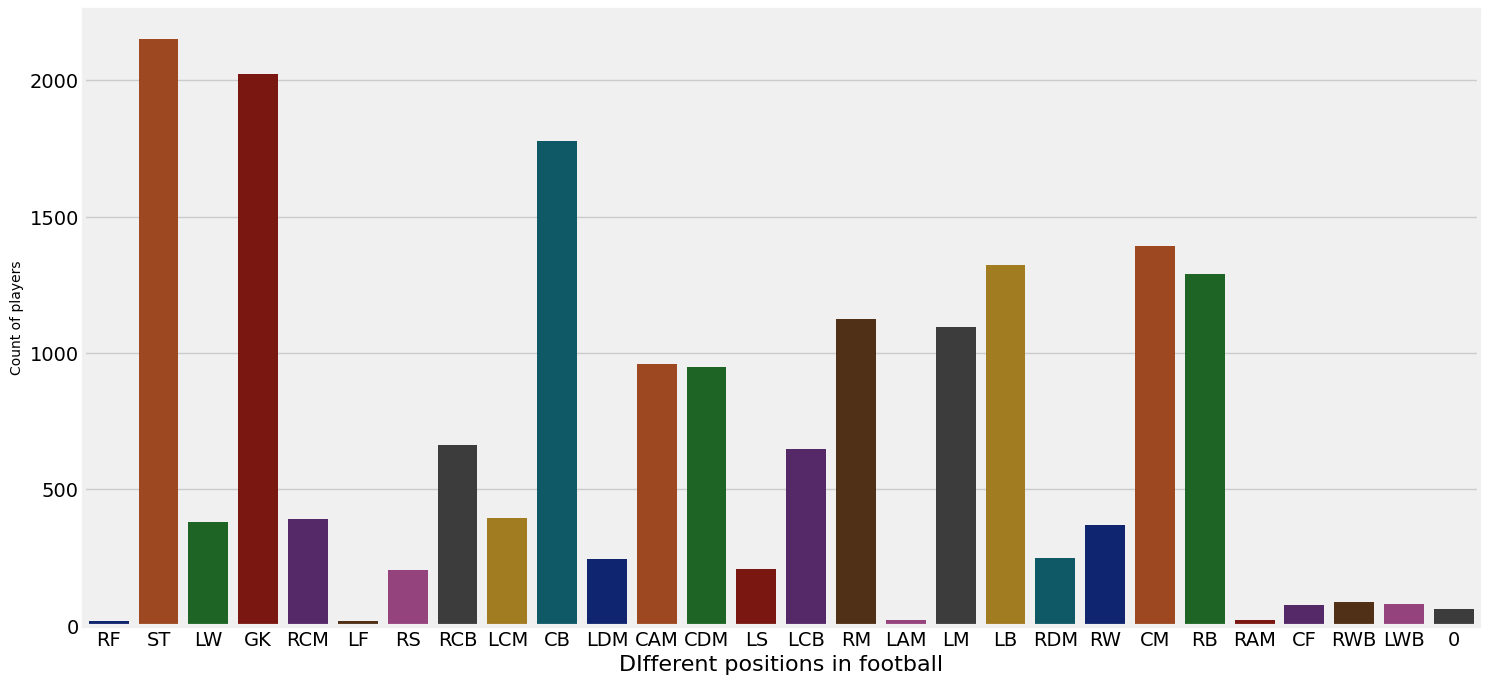

In [38]:
plt.figure(figsize=(18,8))
plt.style.use("fivethirtyeight")
ax=sns.countplot(x="Position",data=data,palette="dark")
ax.set_xlabel(xlabel="DIfferent positions in football",fontsize=16)
ax.set_ylabel(ylabel="Count of players",fontsize=10)
plt.show()

Count of players on basis of height

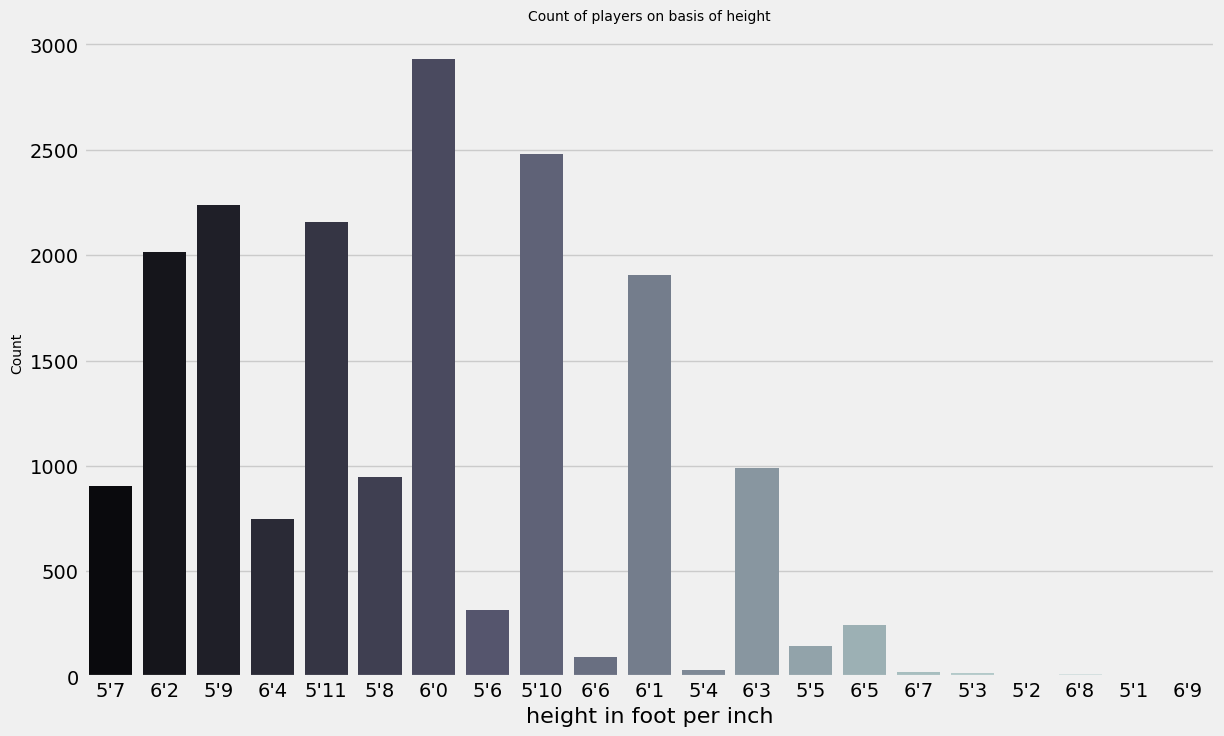

In [39]:
plt.figure(figsize=(13,8))
plt.style.use("fivethirtyeight")
ax=sns.countplot(x="Height",data=data,palette="bone")
ax.set_xlabel(xlabel="height in foot per inch",fontsize=16)
ax.set_ylabel(ylabel="Count",fontsize=10)
ax.set_title("Count of players on basis of height",fontsize=10)
plt.show()

Different workrates of player participating in the fifa

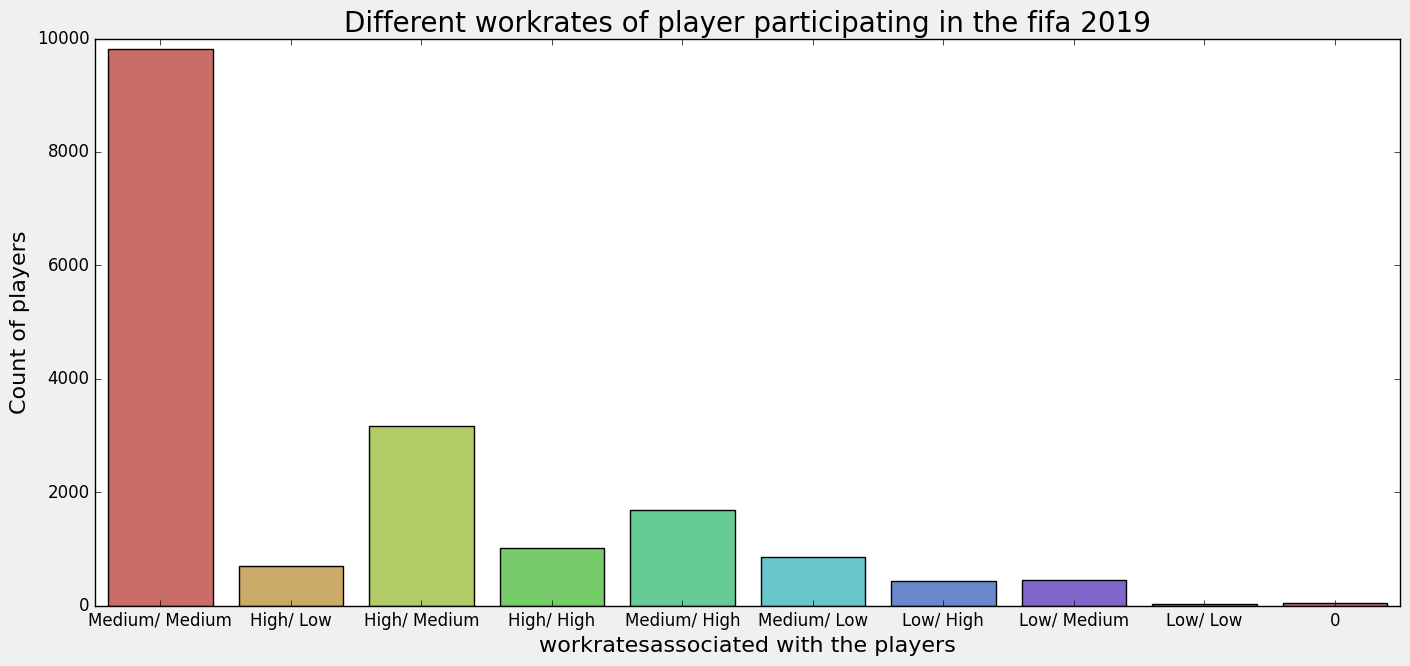

In [40]:
plt.figure(figsize=(15,7))
plt.style.use("classic")
sns.countplot(x="WorkRate",data=data,palette="hls")
plt.xlabel("workratesassociated with the players",fontsize=16)
plt.ylabel(ylabel="Count of players",fontsize=16)
plt.title("Different workrates of player participating in the fifa 2019",fontsize=20)
plt.show()

distribution of overall scores of players from different countries

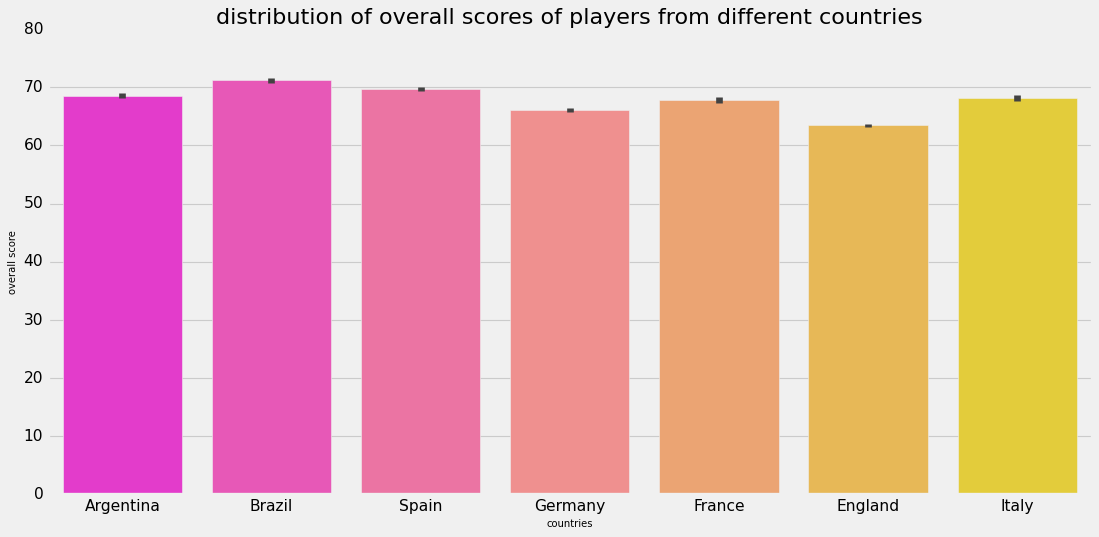

In [41]:
some_countries=("England","Germany","Spain","Argentina","France","Brazil","Italy","Columbia")
data_countries=data.loc[data["Nationality"].isin(some_countries)&data["Overall"]]
plt.rcParams["figure.figsize"]=(15,7)
plt.style.use("fivethirtyeight")
ax=sns.barplot(x=data_countries["Nationality"],y=data_countries["Overall"],palette="spring")
ax.set_xlabel(xlabel="countries",fontsize=9)
ax.set_ylabel(ylabel="overall score",fontsize=9)
ax.set_title(label="distribution of overall scores of players from different countries",fontsize=20)
plt.show()

distribution of overall scores different popular clubs

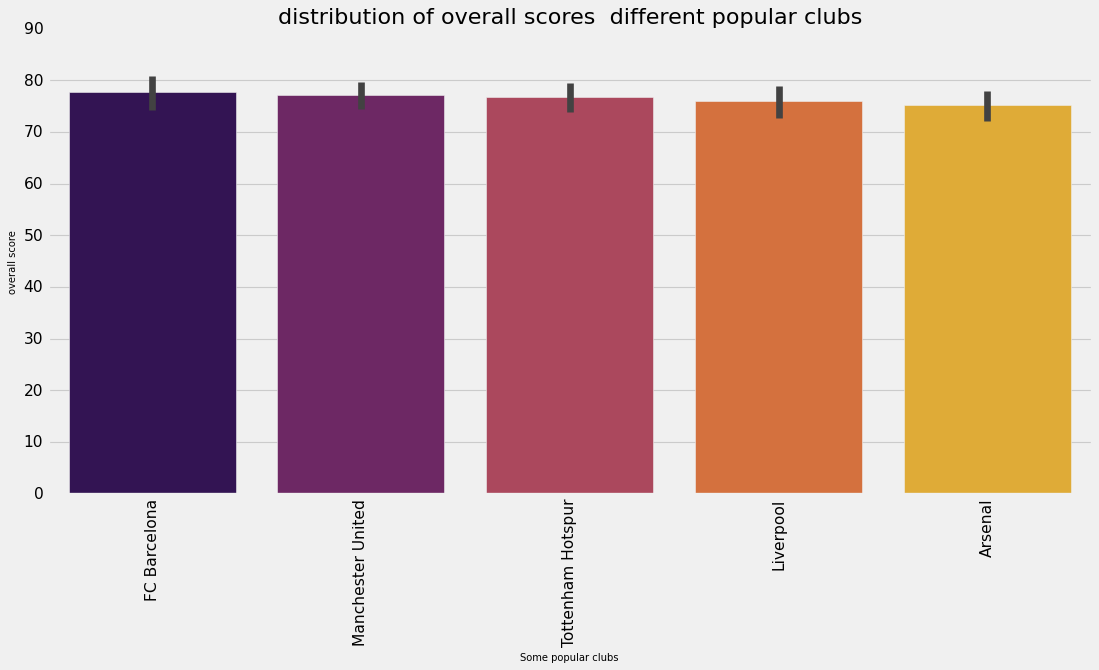

In [42]:
some_clubs=("FC Barcelona","Manchester United","Manchester", "CityChelseaReal", "Madrid Atlético Madrid",  "Tottenham Hotspur","Liverpool","Arsenal")
data_clubs=data.loc[data["Club"].isin(some_clubs) & data["Overall"]]
plt.rcParams["figure.figsize"]=(15,7)
ax=sns.barplot(x=data_clubs["Club"],y=data_clubs["Overall"],palette="inferno")
ax.set_xlabel(xlabel="Some popular clubs",fontsize=9)
ax.set_ylabel(ylabel="overall score",fontsize=9)
ax.set_title(label="distribution of overall scores  different popular clubs",fontsize=20)
plt.xticks(rotation=90)
plt.show()

Visualizing Player 

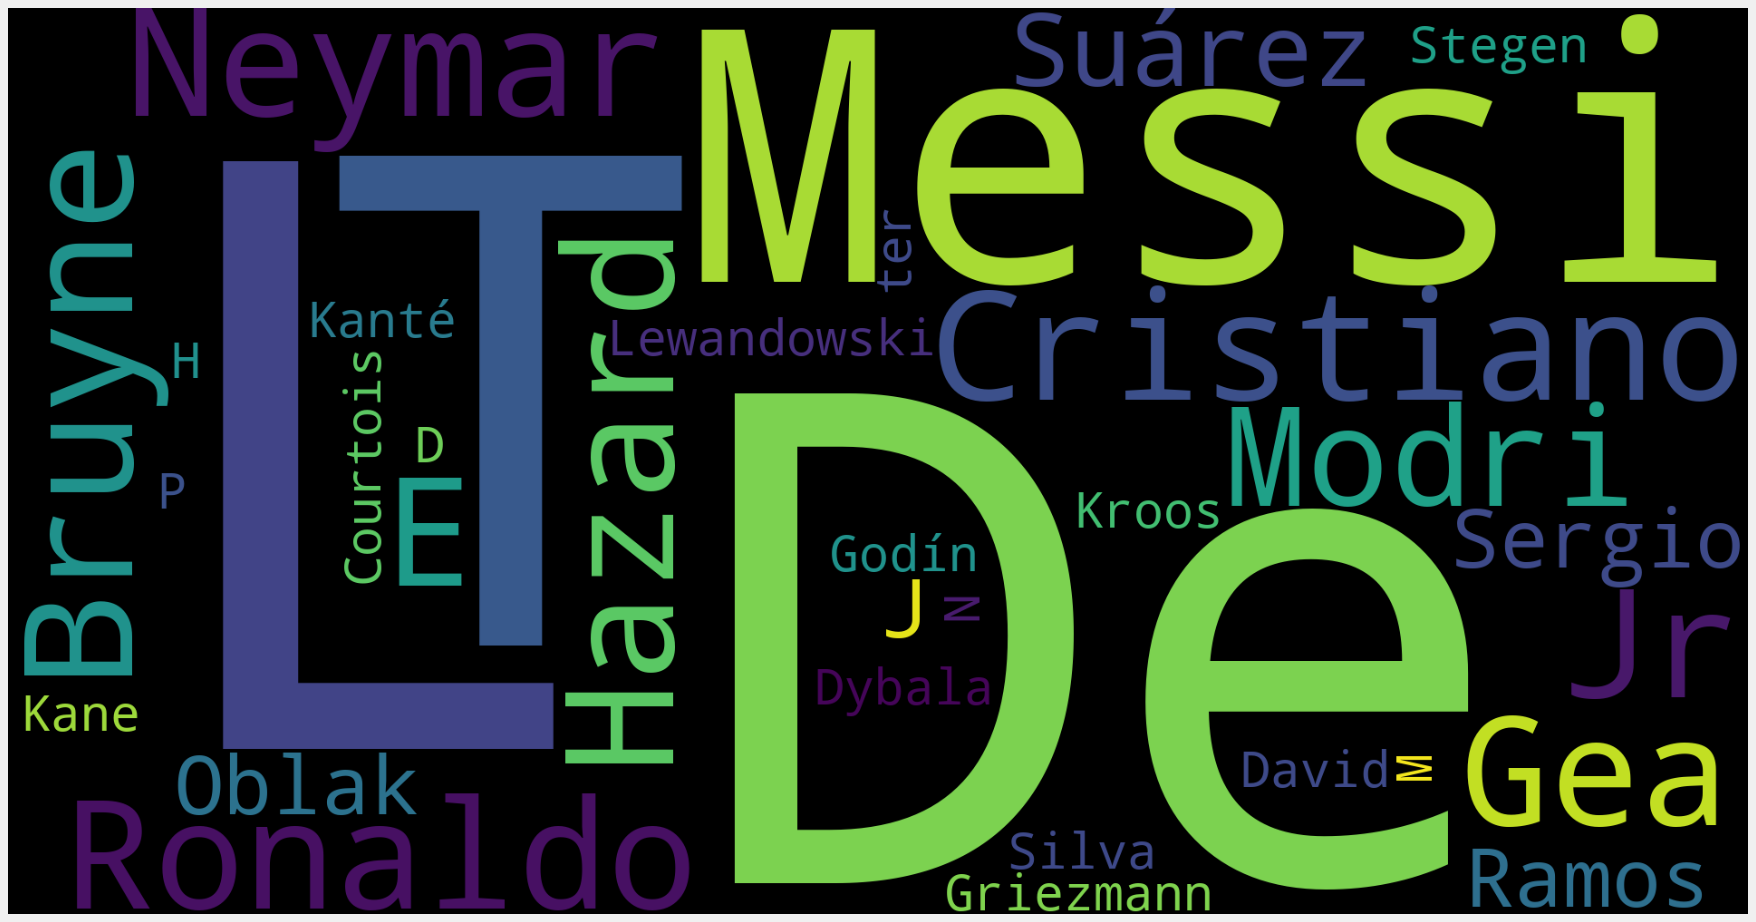

In [43]:
plt.subplots(figsize=(25,15))
wordcloud=WordCloud(background_color="black",width=1920,height=1000).generate(" ".join(data.Name[0:20]))
plt.imshow(wordcloud)
plt.axis("off")
plt.savefig("players.png")
plt.show()

In [ ]:
data.to_csv("cleaned_fifa.csv", index=False)